<a href="https://colab.research.google.com/github/Kaviyasree-N/ML-PROJECT/blob/main/Email_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Searching for CSV files in Colab...

CSV files found:
1. /content/SpamAssasin (1).csv
2. /content/sample_data/california_housing_test.csv
3. /content/sample_data/mnist_train_small.csv
4. /content/sample_data/california_housing_train.csv
5. /content/sample_data/mnist_test.csv

Using file:
/content/SpamAssasin (1).csv

DATASET LOADED
Rows    : 5809
Columns : 7

Original columns:
['sender', 'receiver', 'date', 'subject', 'body', 'label', 'urls']

Standardized columns:
['sender', 'receiver', 'date', 'subject', 'body', 'label', 'urls']

Duplicate emails removed: 0

CLASS DISTRIBUTION
label
Legitimate    4091
Spam          1718
Name: count, dtype: int64

Empty emails removed: 0

TRAIN / TEST DATA
Training samples: 4647
Testing samples: 1162

TF-IDF FEATURE EXTRACTION
Number of TF-IDF features: 15000

Naive Bayes model trained successfully.

MODEL PERFORMANCE
Accuracy  : 97.16%
Precision : 97.26%
Recall    : 93.02%
F1 Score  : 95.10%

CLASSIFICATION REPORT
              precision    recall  f

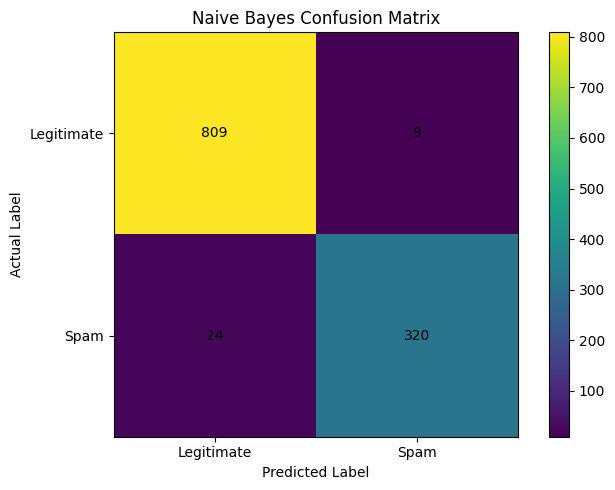



TEST EMAIL 1

EMAIL ANALYSIS
Subject    : Congratulations! You won a prize
URLs       : http://example.com/prize
Prediction : Spam
Confidence : 79.31%


TEST EMAIL 2

EMAIL ANALYSIS
Subject    : Project meeting tomorrow
URLs       : None
Prediction : Legitimate
Confidence : 85.85%

FINAL DATASET
Total emails: 5809

Class distribution:
label
Legitimate    4091
Spam          1718
Name: count, dtype: int64

Saved file:
/content/processed_email_dataset.csv

Sample records:


,sender,receiver,date,subject,body,label,urls
0,Robert Elz <kre@munnari.OZ.AU>,Chris Garrigues <cwg-dated-1030377287.06fa6d@D...,"Thu, 22 Aug 2002 18:26:25 +0700",Re: New Sequences Window,"Date: Wed, 21 Aug 2002 10:54:46 -0500 ...",Legitimate,1
1,Steve Burt <Steve_Burt@cursor-system.com>,"""'zzzzteana@yahoogroups.com'"" <zzzzteana@yahoo...","Thu, 22 Aug 2002 12:46:18 +0100",[zzzzteana] RE: Alexander,"Martin A posted:\nTassos Papadopoulos, the Gre...",Legitimate,1
2,"""Tim Chapman"" <timc@2ubh.com>",zzzzteana <zzzzteana@yahoogroups.com>,"Thu, 22 Aug 2002 13:52:38 +0100",[zzzzteana] Moscow bomber,Man Threatens Explosion In Moscow \n\nThursday...,Legitimate,1
3,Monty Solomon <monty@roscom.com>,undisclosed-recipient: ;,"Thu, 22 Aug 2002 09:15:25 -0400",[IRR] Klez: The Virus That Won't Die,Klez: The Virus That Won't Die\n \nAlready the...,Legitimate,1
4,Stewart Smith <Stewart.Smith@ee.ed.ac.uk>,zzzzteana@yahoogroups.com,"Thu, 22 Aug 2002 14:38:22 +0100",Re: [zzzzteana] Nothing like mama used to make,"> in adding cream to spaghetti carbonara, whi...",Legitimate,1
5,"""Martin Adamson"" <martin@srv0.ems.ed.ac.uk>",zzzzteana@yahoogroups.com,"Thu, 22 Aug 2002 14:50:31 +0100",Re: [zzzzteana] Nothing like mama used to make,> I just had to jump in here as Carbonara is o...,Legitimate,1
6,"""Martin Adamson"" <martin@srv0.ems.ed.ac.uk>",zzzzteana@yahoogroups.com,"Thu, 22 Aug 2002 14:54:25 +0100",[zzzzteana] Playboy wants to go out with a bang,The Scotsman - 22 August 2002\n\n Playboy want...,Legitimate,1
7,Stewart Smith <Stewart.Smith@ee.ed.ac.uk>,zzzzteana@yahoogroups.com,"Thu, 22 Aug 2002 15:01:20 +0100",Re: [zzzzteana] Nothing like mama used to make,Martin Adamson wrote: > > Isn't it just basic...,Legitimate,1
8,"""Martin Adamson"" <martin@srv0.ems.ed.ac.uk>",zzzzteana@yahoogroups.com,"Thu, 22 Aug 2002 15:01:33 +0100",[zzzzteana] Meaningful sentences,The Scotsman\n\n Thu 22 Aug 2002 \n\n Meaningf...,Legitimate,1
9,"""NOI Administrator"" <admin@networksonline.com>",<spamassassin-talk@example.sourceforge.net>,"Thu, 22 Aug 2002 10:16:36 -0400",[SAtalk] SA CGI Configurator Scripts,I have been trying to research via SA mirrors ...,Legitimate,1


In [6]:
# ============================================================
# REAL-TIME AI/ML BASED PHISHING DETECTION AND PREVENTION SYSTEM
# ============================================================
# Model       : Multinomial Naive Bayes
# Feature     : TF-IDF
# Dataset     : Single CSV file
# Platform    : Google Colab
# Classes     : Spam / Legitimate
# ============================================================


# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


# ============================================================
# 2. AUTOMATICALLY FIND CSV FILE
# ============================================================

print("Searching for CSV files in Colab...")

csv_files = []

for root, dirs, files in os.walk("/content"):

    for file in files:

        if file.lower().endswith(".csv"):

            csv_files.append(
                os.path.join(root, file)
            )


if len(csv_files) == 0:

    raise FileNotFoundError(
        "No CSV file found. Upload your CSV to the Colab Files section."
    )


print("\nCSV files found:")

for i, file in enumerate(csv_files):

    print(
        f"{i + 1}. {file}"
    )


# ============================================================
# 3. SELECT CSV
# ============================================================

# If there is only one CSV, automatically use it.
# If there are multiple CSV files, use the first one.

file_path = csv_files[0]

print("\nUsing file:")
print(file_path)


# ============================================================
# 4. LOAD DATASET
# ============================================================

try:

    df = pd.read_csv(
        file_path,
        encoding="utf-8",
        on_bad_lines="skip"
    )

except UnicodeDecodeError:

    df = pd.read_csv(
        file_path,
        encoding="latin-1",
        on_bad_lines="skip"
    )


print("\n============================================================")
print("DATASET LOADED")
print("============================================================")

print(
    "Rows    :",
    len(df)
)

print(
    "Columns :",
    len(df.columns)
)


# ============================================================
# 5. CLEAN COLUMN NAMES
# ============================================================

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
)


print("\nOriginal columns:")

print(
    df.columns.tolist()
)


# ============================================================
# 6. STANDARDIZE COMMON COLUMN NAMES
# ============================================================

column_mapping = {

    "from": "sender",
    "sender_email": "sender",
    "sender email": "sender",
    "mail_from": "sender",

    "to": "receiver",
    "recipient": "receiver",
    "receiver_email": "receiver",
    "receiver email": "receiver",

    "timestamp": "date",
    "email_date": "date",

    "title": "subject",
    "email_subject": "subject",

    "message": "body",
    "email_body": "body",
    "email body": "body",
    "content": "body",
    "text": "body",

    "class": "label",
    "category": "label",
    "type": "label",

    "url": "urls",
    "links": "urls",
    "link": "urls"
}


df = df.rename(
    columns=column_mapping
)


# ============================================================
# 7. DISPLAY STANDARDIZED COLUMNS
# ============================================================

print("\nStandardized columns:")

print(
    df.columns.tolist()
)


# ============================================================
# 8. CHECK REQUIRED COLUMNS
# ============================================================

required_columns = [
    "sender",
    "receiver",
    "date",
    "subject",
    "body",
    "label",
    "urls"
]


missing_columns = [
    column
    for column in required_columns
    if column not in df.columns
]


# ============================================================
# 9. IF SOME OPTIONAL COLUMNS ARE MISSING
# ============================================================

# These columns are useful but not essential for
# text classification.

optional_columns = [
    "sender",
    "receiver",
    "date",
    "urls"
]


for column in optional_columns:

    if column not in df.columns:

        df[column] = ""


# Subject and body are essential.

if "subject" not in df.columns:

    df["subject"] = ""


if "body" not in df.columns:

    raise ValueError(
        "The dataset does not contain an email body/text column."
    )


if "label" not in df.columns:

    raise ValueError(
        "The dataset does not contain a label/class column."
    )


# ============================================================
# 10. HANDLE MISSING VALUES
# ============================================================

for column in df.columns:

    df[column] = (
        df[column]
        .fillna("")
        .astype(str)
    )


# ============================================================
# 11. REMOVE DUPLICATE EMAILS
# ============================================================

before_duplicates = len(df)


df = df.drop_duplicates(
    subset=[
        "sender",
        "subject",
        "body"
    ]
)


duplicates_removed = (
    before_duplicates -
    len(df)
)


print(
    "\nDuplicate emails removed:",
    duplicates_removed
)


# ============================================================
# 12. STANDARDIZE LABELS
# ============================================================

df["label"] = (
    df["label"]
    .str.strip()
    .str.lower()
)


# Common label formats

label_mapping = {

    "spam": "Spam",

    "spam mail": "Spam",

    "spam email": "Spam",

    "1": "Spam",

    "true": "Spam",

    "yes": "Spam",

    "ham": "Legitimate",

    "legitimate": "Legitimate",

    "legit": "Legitimate",

    "normal": "Legitimate",

    "normal mail": "Legitimate",

    "0": "Legitimate",

    "false": "Legitimate",

    "no": "Legitimate"
}


df["label"] = df["label"].replace(
    label_mapping
)


# ============================================================
# 13. REMOVE UNKNOWN LABELS
# ============================================================

valid_labels = [
    "Spam",
    "Legitimate"
]


unknown_labels = (
    df.loc[
        ~df["label"].isin(valid_labels),
        "label"
    ]
    .unique()
)


if len(unknown_labels) > 0:

    print(
        "\nUnknown labels found:",
        unknown_labels
    )

    print(
        "These rows will be removed."
    )


df = df[
    df["label"].isin(valid_labels)
].reset_index(drop=True)


# ============================================================
# 14. CHECK CLASS DISTRIBUTION
# ============================================================

print("\n============================================================")
print("CLASS DISTRIBUTION")
print("============================================================")

print(
    df["label"].value_counts()
)


# ============================================================
# 15. CREATE TEXT FEATURE
# ============================================================

# Subject + body are combined because both contain
# useful information for spam detection.

df["combined_text"] = (
    df["subject"] +
    " " +
    df["body"]
)


# ============================================================
# 16. TEXT CLEANING FUNCTION
# ============================================================

def clean_text(text):

    text = str(text)

    # Lowercase

    text = text.lower()


    # Remove HTML tags

    text = re.sub(
        r"<[^>]+>",
        " ",
        text
    )


    # Replace URLs with a token

    text = re.sub(
        r"https?://\S+|www\.\S+",
        " URL ",
        text
    )


    # Replace email addresses

    text = re.sub(
        r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b",
        " EMAIL ",
        text
    )


    # Remove special characters

    text = re.sub(
        r"[^a-zA-Z0-9\s]",
        " ",
        text
    )


    # Remove extra spaces

    text = re.sub(
        r"\s+",
        " ",
        text
    )


    return text.strip()


# ============================================================
# 17. APPLY TEXT CLEANING
# ============================================================

df["clean_text"] = (
    df["combined_text"]
    .apply(clean_text)
)


# ============================================================
# 18. REMOVE EMPTY EMAILS
# ============================================================

before_empty = len(df)


df = df[
    df["clean_text"].str.len() > 0
].reset_index(drop=True)


print(
    "\nEmpty emails removed:",
    before_empty - len(df)
)


# ============================================================
# 19. PREPARE X AND Y
# ============================================================

X = df["clean_text"]

y = df["label"]


# ============================================================
# 20. TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y
)


print("\n============================================================")
print("TRAIN / TEST DATA")
print("============================================================")

print(
    "Training samples:",
    len(X_train)
)

print(
    "Testing samples:",
    len(X_test)
)


# ============================================================
# 21. TF-IDF FEATURE EXTRACTION
# ============================================================

vectorizer = TfidfVectorizer(

    max_features=15000,

    stop_words="english",

    ngram_range=(1, 2),

    min_df=2
)


# Fit ONLY on training data

X_train_tfidf = (
    vectorizer
    .fit_transform(X_train)
)


# Transform test data

X_test_tfidf = (
    vectorizer
    .transform(X_test)
)


print("\n============================================================")
print("TF-IDF FEATURE EXTRACTION")
print("============================================================")

print(
    "Number of TF-IDF features:",
    X_train_tfidf.shape[1]
)


# ============================================================
# 22. CREATE NAIVE BAYES MODEL
# ============================================================

model = MultinomialNB()


# ============================================================
# 23. TRAIN MODEL
# ============================================================

model.fit(
    X_train_tfidf,
    y_train
)


print(
    "\nNaive Bayes model trained successfully."
)


# ============================================================
# 24. PREDICT TEST DATA
# ============================================================

y_pred = model.predict(
    X_test_tfidf
)


# ============================================================
# 25. CALCULATE PERFORMANCE
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)


precision = precision_score(
    y_test,
    y_pred,
    pos_label="Spam",
    zero_division=0
)


recall = recall_score(
    y_test,
    y_pred,
    pos_label="Spam",
    zero_division=0
)


f1 = f1_score(
    y_test,
    y_pred,
    pos_label="Spam",
    zero_division=0
)


# ============================================================
# 26. DISPLAY RESULTS
# ============================================================

print("\n============================================================")
print("MODEL PERFORMANCE")
print("============================================================")

print(
    f"Accuracy  : {accuracy * 100:.2f}%"
)

print(
    f"Precision : {precision * 100:.2f}%"
)

print(
    f"Recall    : {recall * 100:.2f}%"
)

print(
    f"F1 Score  : {f1 * 100:.2f}%"
)


# ============================================================
# 27. CLASSIFICATION REPORT
# ============================================================

print("\n============================================================")
print("CLASSIFICATION REPORT")
print("============================================================")

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)


# ============================================================
# 28. CONFUSION MATRIX
# ============================================================

labels = [
    "Legitimate",
    "Spam"
]


cm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels
)


print("\n============================================================")
print("CONFUSION MATRIX")
print("============================================================")

print(cm)


# ============================================================
# 29. DISPLAY CONFUSION MATRIX
# ============================================================

plt.figure(
    figsize=(7, 5)
)

plt.imshow(cm)

plt.title(
    "Naive Bayes Confusion Matrix"
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "Actual Label"
)

plt.xticks(
    [0, 1],
    labels
)

plt.yticks(
    [0, 1],
    labels
)


for i in range(
    len(labels)
):

    for j in range(
        len(labels)
    ):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )


plt.colorbar()

plt.tight_layout()

plt.show()


# ============================================================
# 30. REAL-TIME EMAIL PREDICTION FUNCTION
# ============================================================

def predict_email(
    subject,
    body,
    urls=""
):

    # Combine subject and body

    email_text = (
        str(subject) +
        " " +
        str(body)
    )


    # Clean email

    cleaned_text = clean_text(
        email_text
    )


    # Convert to TF-IDF

    email_vector = (
        vectorizer
        .transform(
            [cleaned_text]
        )
    )


    # Predict

    prediction = model.predict(
        email_vector
    )[0]


    # Get probabilities

    probabilities = (
        model.predict_proba(
            email_vector
        )[0]
    )


    # Get highest probability

    confidence = (
        max(probabilities) * 100
    )


    print("\n============================================================")
    print("EMAIL ANALYSIS")
    print("============================================================")

    print(
        "Subject    :",
        subject
    )

    print(
        "URLs       :",
        urls if urls else "None"
    )

    print(
        "Prediction :",
        prediction
    )

    print(
        "Confidence :",
        f"{confidence:.2f}%"
    )


    return prediction


# ============================================================
# 31. TEST EMAIL 1 - SPAM
# ============================================================

print("\n\nTEST EMAIL 1")

predict_email(

    subject="Congratulations! You won a prize",

    body="""
    Congratulations!
    You have been selected as a winner.
    Click the link below to claim your prize.
    This offer expires today.
    """,

    urls="http://example.com/prize"
)


# ============================================================
# 32. TEST EMAIL 2 - LEGITIMATE
# ============================================================

print("\n\nTEST EMAIL 2")

predict_email(

    subject="Project meeting tomorrow",

    body="""
    Hi Team,

    This is a reminder that our project meeting
    will be held tomorrow at 10 AM.

    Please bring your project report.

    Regards,
    Project Team
    """,

    urls=""
)


# ============================================================
# 33. CREATE FINAL CLEAN CSV
# ============================================================

final_columns = [
    "sender",
    "receiver",
    "date",
    "subject",
    "body",
    "label",
    "urls"
]


output_file = (
    "/content/processed_email_dataset.csv"
)


df[
    final_columns
].to_csv(

    output_file,

    index=False,

    encoding="utf-8"
)


# ============================================================
# 34. FINAL DATASET SUMMARY
# ============================================================

print("\n============================================================")
print("FINAL DATASET")
print("============================================================")

print(
    "Total emails:",
    len(df)
)

print(
    "\nClass distribution:"
)

print(
    df["label"].value_counts()
)

print(
    "\nSaved file:"
)

print(
    output_file
)


# ============================================================
# 35. DISPLAY SAMPLE DATA
# ============================================================

print("\nSample records:")

display(
    df[
        final_columns
    ].head(10)
)